# BEE 4310/6310: Environmental Statistics and Learning  <br> Assignment #6 (5 pts)

**Include responses to everything below in bold (including plots), and make sure your final assignment is well organized in a single markdown PDF submitted to Canvas. This makes it easier to grade (and easier to give partial credit).**

**Remember to include an acknowledgement at the bottom of this assignment if generative AI was used for coding support, including a list of the problems for which it was used.**

<img src="LearningOutcomes_6.png" width="1000"/>

**Techniques and Topics:** 
- Neural Networks


In this assignment, we will use neural networks to predict crop yield, using information related to climate (rainfall and temperature), as well as management practices (the amount of pesticides applied).

<img src="Ag_Yield.png" width="500"/>

The problems below walk you through building a neural network from scratch, so that you can become familiar with how we translate the math shown in the course notes into code. This will also give you a sense of what happens "under the hood" in the various packages available in Python (and other coding languages) that allow you to build and train a neural network in just a couple lines of code.

1. Import the following packages: numpy, pandas, matplotlib.pyplot, and OneHotEncoder from sklearn.preprocessing. Note: you will need to import other packages further down in the assignment. 

    Download the Global_Crop_Yields_and_Climate.csv file from Canvas under Assignment 6 and load in this data as a Pandas dataframe called 'df'. This file contains:
    - Information by country ('Area'; 101 countries total) and year (1990-2013)
    - A number of crops grown in these countries ('Item') - e.g., maize, potatoes, wheat
    - The yield associated with that crop in hectograms per hectare ('hg/ha_yield')
    - Climate information: average annual rainfall ('average_rain_fall_mm_per_year'), and average temp for a given year ('avg_temp')
    - Management information: the amount of pesticides applied  ('pesticides_tonnes')

We'll also fix a random seed to enable reproducibility of the results we get - it has been fixed to 44 below (do not change this).

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Global_Crop_Yields_and_Climate.csv") 

# Fix random seed for reproducibility - DO NOT CHANGE SEED
np.random.seed(44)


2. The models we will further build below are going to focus on predicting whether potato yields for a given country and year are above or below the global median based on the following four predictors: 
- rainfall
- temperature
- pesticides applied 
- country (coded as 'area')

    a) Filter the dataset to only include information on potato yield, and then split the data into a training set for the years 1990-2008 and a testing set for the years 2009-2013.

    b) Create a column called 'above_median' that is either 0 or 1, indicating whether the potato yield is below or above the median potato yield for the training dataset.

    c) Create the training and testing predictor arrays (X_train and X_test) by combining the standardized numeric variables (rainfall, pesticides, average temperature) with a one-hot encoded version of the categorical variable (Area). Recall that to standardize numeric variables, we subtract the mean and divide by the standard deviation of that variable *based on the training data only*. 

    d) Create the target arrays (y_train and y_test) by extracting the above_median column as NumPy arrays from the training and test datasets. These will be binary (0 = below/equal to median, 1 = above median).

*We provide the code for this below, so that you can focus your time/energy on building neural networks!*

In [5]:
# Filter df for Potatoes:
df_potatoes = df[df['Item'] == 'Potatoes'].copy()

# Define numeric features and categorical feature, and target (what we're trying to predict)
numeric_features = ['average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp'] 
cat_feature = ['Area']
target = 'hg/ha_yield'

# Split into training and test sets based on year
train_df = df_potatoes[df_potatoes['Year'] <= 2008].copy()
test_df = df_potatoes[df_potatoes['Year'] >= 2009].copy()

# Compute median yield from training set only
median_yield_train = train_df[target].median()

# Create binary target: 1 = above global median, 0 = below gloabl median
train_df['above_median'] = (train_df[target] > median_yield_train).astype(int)
test_df['above_median'] = (test_df[target] > median_yield_train).astype(int)

# Extract numeric arrays
X_train_num = train_df[numeric_features].to_numpy()
X_test_num = test_df[numeric_features].to_numpy()

# Standardize numeric features
train_means = X_train_num.mean(axis=0)
train_stds = X_train_num.std(axis=0)

X_train_num_std = (X_train_num - train_means) / train_stds
X_test_num_std = (X_test_num - train_means) / train_stds

# One-hot encode 'Area' (country)
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_area = encoder.fit_transform(train_df[cat_feature])
X_test_area = encoder.transform(test_df[cat_feature])

# Concatenate standardized numeric + one-hot categorical
X_train_std = np.hstack([X_train_num_std, X_train_area])
X_test_std = np.hstack([X_test_num_std, X_test_area])

# Targets
y_train = train_df['above_median'].to_numpy()
y_test = test_df['above_median'].to_numpy()



3. (3 pt) Build a neural network from scratch (with NumPy)!

    We’re now going to implement a simple feedforward neural network step by step. We're going to start with the simplest neural network: it will have one layer, one node, and will use the sigmoid activation function to get a final output that's between 0 and 1 (i.e., a probability of being above the global median potato yield). 
    
    This simple neural network is essentially just a logistic regression, and all of the math is in your notes. However, implementing it via the steps below will let you see how neural networks are built, trained, and used for prediction, while keeping the math relatively straightforward.


    The overall process will be broken into the following key components:

    Step A) (0.5 points) Define activation function(s)
    
    Step B) Initialize the model parameters (weights and biases)

    Step C) (0.5 points) Implement forward propagation
    
    Step D) (0.5 points) Define the cost/loss function (binary cross-entropy)

    Step E) (0.5 points) Implement backpropagation to compute gradients

    Step F) Update parameters (weights and biases) using gradient descent

    Step G) (0.5 points) Train the model by looping through forward + backward passes

    Step H) (0.5 points) Evaluate the model by making predictions on the test set

    Starter code and instructions for each part are provided below.

    **For this question, the main "outputs" of each step are the functions you are asked to create. In the earlier steps (A-E), you will test each function with simple "dummy" inputs to ensure they are working before moving forward. In steps G-H, you will use the yield data described above to actually train your model and make final predictions.** 

#### **(0.5 points)** Step A – Define Activation Function

a) Write a function to compute the sigmoid activation. This function should take some input 'z' (which may be a scalar, vector, or matrix) and returns the elementwise activation.

b) Test this function on a small NumPy array (z= np.array([-2, -0.5, 0, 1, 3])) to make sure it returns sensible results. Recall that the activation is applied element-wise to each entry in the array.
    
**Print the output that your activation function gives you when applied to this array.**

    

In [6]:
#define a sigmoid function here
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

#apply the sigmoid function to the dummy input z = np.array([-2, -0.5, 0, 1, 3]) and print the result
z = np.array([-2, -0.5, 0, 1, 3])
sigmoid_result = sigmoid(z)
print("Sigmoid results:", sigmoid_result)

Sigmoid results: [0.11920292 0.37754067 0.5        0.73105858 0.95257413]


#### Step B – Initialize Parameters

This function is given to you. It initializes model parameters, by doing the following:
- The weights (W) are initialized as small random numbers (shape: number of features × 1).
- The scalar bias (b) is initialized at zero.
- The function returns both W and b.

In [7]:
def initialize_parameters(n_x):
    """
    Initialize weights and bias for a single neuron.
    n_x: number of input features
    Returns:
        Initialized W and b
    """
    W = np.random.randn(n_x, 1) * 0.01  
    b = 0.0
    return W, b


#### **( 0.5 points)** Step C – Forward Propagation

**a) Write a function that computes the forward pass. This function should:**

- Take X, W, and b as arguments
- Compute Z, i.e., the linear combination of the inputs X with the weights W and bias b
- Apply the sigmoid activation A=σ(Z) - use your function from Step A above
- Return the activation A

**b) Test this function using dummy values for X, W, and b** 
- Here we define m=2 dummy observations for X, where each observation contains 5 variables. We also specify fixed W and b values (instead of random initializations), to make grading easier :)
    - X_dummy = np.array([[-3, -1, 0, 1, 3],[-4, -2, 0, 2, 4]])
    - W_dummy = np.array([-0.5,0.3,0.1,-0.2,0.4])
    - b_dummy = 0

**Print the output of the foward pass with these dummy inputs (i.e., the 'prediction' of the model).**

In [8]:
# Forward propagation function
def forward_propagation(X, W, b):
    """
    Forward pass for logistic regression model
    X: (m, n) input data
    W: (n, 1) weights
    b: scalar bias
    Returns:
        A: (m, 1) sigmoid activations
    """
    Z = np.dot(X, W) + b # linear transformation
    A = sigmoid(Z) # apply sigmoid activation (non-linear)

    return A


#define dummy values for X, W, and b and print the forward propagation function using these inputs:
X_dummy = np.array([[-3, -1, 0, 1, 3],[-4, -2, 0, 2, 4]])
W_dummy = np.array([-0.5,0.3,0.1,-0.2,0.4])
b_dummy = 0

forward_propagation(X_dummy, W_dummy, b_dummy)
print("Forward propagation result:", forward_propagation(X_dummy, W_dummy, b_dummy))

Forward propagation result: [0.90024951 0.93086158]


####  **( 0.5 points)** Step D – Cost/Loss Function

**a) Write a function to compute the logistic regression cost (binary cross-entropy):**

- This function should take as arguments the activations A and observed responses Y
- In the loss function, add a small constant eps (e.g., 1e-8) to A to avoid instances of log(0) in the loss. 
- Return the cost as a scalar.
    - Remember, the cost is the average of the loss across observations

**b) Test this function using dummy values for X, W, b, and y:**
- Here we define m=2 dummy observations for both X and y.
    - X_dummy = np.array([[-3, -1, 0, 1, 3],[-4, -2, 0, 2, 4]])
    - W_dummy = np.array([-0.5,0.3,0.1,-0.2,0.4])
    - b_dummy = 0
    - y_dummy = np.array([1,0])
- Using these inputs, compute a forward pass
- Then compute the cost

**Print the output of the cost with these dummy inputs.**

In [9]:
# Function for computing cost (average loss calculated over a batch of observations)
def compute_cost(A, Y):
    """
    Logistic regression cross-entropy cost
    A: (m, 1) predicted probabilities
    Y: (m, 1) true labels (0/1)
    Returns:
        cost
    """
    m = Y.shape[0]
    Y = Y.reshape(-1, 1)   # ensure column vector (this line is needed to make future math computationally efficient)
    
    # Calculate cost, including addition of a small constant eps=1e-8 to A to avoid log(0)
    eps = 1e-8
    cost = - (1/m) * np.sum(Y * np.log(A + eps) + (1 - Y) * np.log(1 - A + eps))

    return cost


#define dummy values for X, W, b, and y and print the cost function using these inputs:
X_dummy = np.array([[-3, -1, 0, 1, 3],[-4, -2, 0, 2, 4]])
W_dummy = np.array([-0.5,0.3,0.1,-0.2,0.4])
b_dummy = 0
y_dummy = np.array([1,0])

print("Cost function result:", compute_cost(forward_propagation(X_dummy, W_dummy, b_dummy), y_dummy))

Cost function result: 2.5767278783672327


#### **(0.5 points)** Step E – Backward Propagation

**a) Write a function that performs backward propagation:** 

- The function should take as arguments the input X, activations A, and true labels y, and returns the partial derivative of the cost function with respect to the weights and bias, i.e., dJ_dW and dJ_db.

- Hint: derive gradients for the weights and bias (i.e., dJ_dW and dJ_db) using the formulas in the class notes.

**b) Test this function using the same X_dummy and y_dummy values you created in Step D above.** 
- **Compute and print the gradients dJ_dW and dJ_db**

In [10]:
def backward_propagation(X, A, Y):
    """
    Compute gradients for logistic regression
    Returns:
        gradients dJ_dW, dJ_db
    """
    m = Y.shape[0]
    Y = Y.reshape(-1, 1)      #ensure column vector 
    A = A.reshape(-1, 1)      #ensure column vector

    # Compute dJ_dW and dJ_db
    dJ_dW = (1/m) * np.dot(X.T, (A - Y))  # Gradient w.r.t. weights
    dJ_db = (1/m) * np.sum(A - Y)          # Gradient w.r.t. bias

    return dJ_dW, dJ_db


#print out gradients here using the dummy inputs:
print("Backward propagation gradients:", backward_propagation(X_dummy, forward_propagation(X_dummy, W_dummy, b_dummy), y_dummy))

Backward propagation gradients: (array([[-1.71209743],
       [-0.88098634],
       [ 0.        ],
       [ 0.88098634],
       [ 1.71209743]]), np.float64(0.41555554526848404))


#### Step F – Gradient Descent Update

**Write a function to update the parameters using gradient descent, with a specified learning_rate.** 
- The function should take as input the original values of W and b, along with the gradients of the cost with respect to W and b
- The function should return the updated W and b (after a single "update").

In [11]:
def update_parameters(W, b, dJ_dW, dJ_db, learning_rate):
    """
    Updates parameters with gradient descent
    Returns:
        updated W, b
    """

    #update parameters here
    W = W - learning_rate * dJ_dW
    b = b - learning_rate * dJ_db

    return W, b


#### **(0.5 point)** Step G – Training Loop

**a) Combine everything into a training function that takes as input: X, Y, learning_rate (set to 0.01), num_iterations (set to 200,000).** The function should perform the following:

- Initialize parameters

- Repeat for a set number of iterations:

    - Forward propagation

    - Compute loss

    - Backward propagation

    - Update parameters

    - Keep track of cost so you can monitor how cost changed during training.
    
    - The function should return the trained W, b, and the cost at each iteration


**b) After building this function, run your training loop to obtain the trained W and b for the agricultural data we developed in Problem #2 above. When you do this, think carefully about what X and Y you should pass into your training function.** 

**Plot cost over iterations to confirm that cost was reduced during training.**

In [19]:
def train_model(X, Y, learning_rate=0.01, num_iterations=200000):
    """
    Trains the model on a set of X and Y values
    Returns:
        final trained W, b, along with a list of costs across iterations
    """

    # Get the shape of X
    n_x = X.shape[1]

    # Store costs in this empty list so you can plot training curve later
    costs = []
    
    # Initialize parameters
    params = initialize_parameters(n_x)
    W, b = params
    
    # Loop through iterations:
    for i in range(num_iterations):
        # Forward propagation
        A = forward_propagation(X, W, b)
        
        # Compute cost
        cost = compute_cost(A, Y)
        
        # Backward propagation
        dJ_dW, dJ_db = backward_propagation(X, A, Y)
        
        # Update parameters
        W, b = update_parameters(W, b, dJ_dW, dJ_db, learning_rate)
        
        # Store cost every 1000 iterations
        costs.append(cost)
            
    
    return W, b, costs


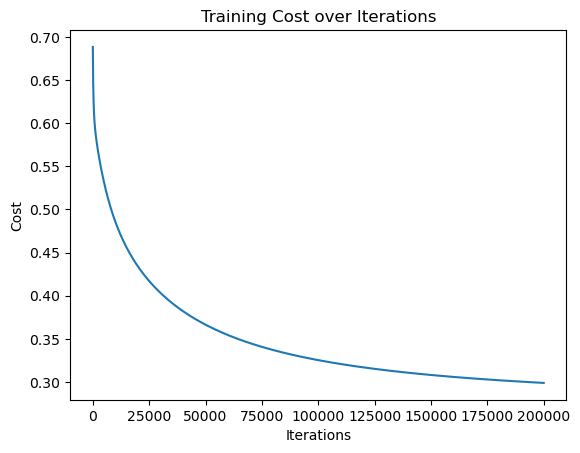

In [21]:
# Compute trained W and b using training function and the agricultural data from Problem #2
W,b,costs = train_model(X_train_std, y_train, learning_rate=0.01, num_iterations=200000)

# Plot cost over iterations
plt.plot(costs)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Training Cost over Iterations')
plt.show()

#### **(0.5 point)** Step H – Prediction

**a) Write a function that makes predictions using provided weights and bias:**
- This function should take as inputs a set of inputs X and parameters W and b
- First, compute the activations A using X, W, and b
- Then, convert A to binary predictions (A_binary): 1 if the output is > 0.5, 0 otherwise.

**b) Use this function to make predictions on both the training and testing sets from the agricultural dataset, based on your trained weights and bias from Step G above. Report the training and testing accuracy, where accuracy is the percentage of predictions the model got correct.**

In [22]:
# Function for making predictions
def predict_NN(X, W, b):
    """
    Produces predictions for a given set of inputs X and W and b
    Returns:
        a set of binary predictions
    """    
    
    #compute final model activations
    A = forward_propagation(X, W, b)

    #convert to binary predictions
    A_binary = (A >= 0.5).astype(int)
    
    return A_binary

In [23]:
# Make predictions on training set; calculate accuracy
A_binary_train = predict_NN(X_train_std, W, b)

# Make predictions on test set; calculate accuracy
A_binary_test = predict_NN(X_test_std, W, b)

# Report training and testing accuracy
train_accuracy = np.mean(A_binary_train.flatten() == y_train.flatten())
test_accuracy = np.mean(A_binary_test.flatten() == y_test.flatten())

print("Training accuracy:", train_accuracy * 100, "%")
print("Testing accuracy:", test_accuracy * 100, "%")

Training accuracy: 85.12173128944995 %
Testing accuracy: 79.66280295047419 %


4. (1 pt) Build a more complex neural network, but with scikit-learn.

    Instead of coding everything from scratch, we can use scikit-learn’s MLPClassifier (from sklearn.neural_network), which provides a convenient interface for building and training feedforward neural networks, and allows us to easily create models that are much more complex.

    a) **Using MLPClassifier (refer to the documentation), create a neural network with the following:**

    - One hidden layer of 3 neurons that uses the ReLU activation function in the hidden layer.

    - Select 'sgd' as the solver (this is stochastic gradient descent - "regular" gradient descent isn't an option in this package).

    - Set random_state to 44 within the MLPClassifier (when we set the random seed in the beginning via np.random.seed(44), this only sets the seed for Numpy's random number generator, not necessarily the random number generator used by packages like scikit-learn.)


    b) Train the model on the training data from the agricultural dataset, and use the trained model to predict both training and testing labels. **Report the accuracy on both sets and compare it with the accuracy you reported in Question 3.** *Note: you can either compute the accuracy the way you did in previous questions, or you can use accuracy_score from sklearn.metrics.*

In [24]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Define the model
model4 = MLPClassifier(hidden_layer_sizes=(3,), activation='relu', solver='sgd', random_state=44)

# Fit on training data
model4.fit(X_train_std, y_train)

# Make predictions
y_train_pred = model4.predict(X_train_std)
y_test_pred = model4.predict(X_test_std)

# Caclulate and report accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training accuracy:", train_accuracy * 100, "%")
print("Testing accuracy:", test_accuracy * 100, "%")



Training accuracy: 75.89419897805831 %
Testing accuracy: 74.3940990516333 %


/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


The MLPClassifier achieved about 75.9% training accuracy and 74.4% testing accuracy. These results are slightly lower than the model I built from scratch, which performed better on both sets.

5. (1 pt): Using GridSearchCV in scikit-learn, tune two hyperparameters of the MLP Classifier using grid search. Specifically, try the following values for the number of neurons and the learning rate:
- number of neurons: 1, 2, 3, 4, 5
- learning rate: 0.005, 0.01, 0.1

**Report the selected hyperparameters and the training and test set accuracy associated with these hyperparameters. Were you able to improve test set performance compared to Question 4?**

In [25]:
from sklearn.model_selection import GridSearchCV

# Define the model
model5 = MLPClassifier( hidden_layer_sizes=(3,), activation='relu', solver='sgd', random_state=44)

# Define parameter grid
param_grid = {
    'hidden_layer_sizes': [(1,), (2,), (3,), (4,), (5,)],
    'learning_rate_init': [0.005, 0.01, 0.1]
}

# Grid search (using cross-validation)
best_model5 = GridSearchCV( estimator = model5, param_grid = param_grid, cv=5)

# Refit on training data with best parameters from grid search
best_model5.fit(X_train_std, y_train)

# Make final predictions
y_pred_train = best_model5.predict(X_train_std)
y_pred_test = best_model5.predict(X_test_std)

# Caclulate and report accuracy
train_acc = np.mean(y_pred_train == y_train)
test_acc = np.mean(y_pred_test == y_test)

print("Training accuracy:", train_acc * 100, "%")
print("Testing accuracy:", test_acc * 100, "%")
print("Best parameters:", best_model5.best_params_)
print("Best cross-validation accuracy:", best_model5.best_score_)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_

Training accuracy: 85.84310189359783 %
Testing accuracy: 70.91675447839832 %
Best parameters: {'hidden_layer_sizes': (1,), 'learning_rate_init': 0.005}
Best cross-validation accuracy: 0.6363336268599427


/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


GridSearchCV selected 1 neuron with a learning rate of 0.005 as the best combination. This model achieved about 85.8% training accuracy and 70.9% testing accuracy. The test accuracy is lower than in Question 4, so hyperparameter tuning did not improve performance.

GitHub Copilot was active for the whole assignment.